# *Unveiling the Android App Market: Analyzing Google Play Store Data*

This project analyzes the Google Play Store dataset to understand app market dynamics, including app categories, ratings, installs, pricing, and user sentiment.

## 🎯 *Objectives*
- Analyze distribution of apps across categories
- Study factors affecting app ratings
- Explore relationship between installs, reviews, and ratings
- Compare free vs paid apps
- Analyze pricing trends
- Understand user sentiment from reviews

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
sns.set_style("whitegrid")
sns.set_palette("Set2")

In [ ]:
## Load datasets

apps = pd.read_csv("apps.csv")
reviews = pd.read_csv("user_reviews.csv")

In [5]:
apps.head()

,Unnamed: 0,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19.0,"10,000+",Free,0,Everyone,Art & Design,07-Jan-18,1.0.0,4.0.3 and up
1,1,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,15-Jan-18,2.0.0,4.0.3 and up
2,2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7,"5,000,000+",Free,0,Everyone,Art & Design,01-Aug-18,1.2.4,4.0.3 and up
3,3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25.0,"50,000,000+",Free,0,Teen,Art & Design,08-Jun-18,Varies with device,4.2 and up
4,4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8,"100,000+",Free,0,Everyone,Art & Design;Creativity,20-Jun-18,1.1,4.4 and up


In [6]:
apps.shape

(9659, 14)

In [7]:
apps.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9659 entries, 0 to 9658
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      9659 non-null   int64  
 1   App             9659 non-null   object 
 2   Category        9659 non-null   object 
 3   Rating          8196 non-null   float64
 4   Reviews         9659 non-null   int64  
 5   Size            8432 non-null   float64
 6   Installs        9659 non-null   object 
 7   Type            9659 non-null   object 
 8   Price           9659 non-null   object 
 9   Content Rating  9659 non-null   object 
 10  Genres          9659 non-null   object 
 11  Last Updated    9659 non-null   object 
 12  Current Ver     9651 non-null   object 
 13  Android Ver     9657 non-null   object 
dtypes: float64(2), int64(2), object(10)
memory usage: 1.0+ MB


## 🧹 *Data Cleaning*

The dataset contained inconsistencies such as incorrect data types, missing values, and unnecessary columns. These were cleaned to ensure accurate analysis.

In [8]:
apps= apps.drop(columns=['Unnamed: 0'])

In [9]:
apps.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19.0,"10,000+",Free,0,Everyone,Art & Design,07-Jan-18,1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,15-Jan-18,2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7,"5,000,000+",Free,0,Everyone,Art & Design,01-Aug-18,1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25.0,"50,000,000+",Free,0,Teen,Art & Design,08-Jun-18,Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8,"100,000+",Free,0,Everyone,Art & Design;Creativity,20-Jun-18,1.1,4.4 and up


In [10]:
apps['Installs'].head()

0        10,000+
1       500,000+
2     5,000,000+
3    50,000,000+
4       100,000+
Name: Installs, dtype: object

In [11]:
apps['Installs']=apps['Installs'].str.replace('+', '',regex=False)
apps['Installs']= apps['Installs'].str.replace(',', '', regex=False)
apps['Installs']= apps['Installs'].astype(int)

In [12]:
apps['Installs'].head()
apps['Installs'].dtype

dtype('int64')

In [13]:
apps['Price'].head()

0    0
1    0
2    0
3    0
4    0
Name: Price, dtype: object

In [14]:
apps['Price']= apps['Price'].str.replace('$', '', regex=False)
apps['Price']= apps['Price'].astype(float)

In [15]:
apps['Price'].head()
apps['Price'].dtype

dtype('float64')

In [16]:
def convert_size(size):
    if pd.isna(size):
        return None
    size= str(size)
    if 'M' in size:
        return float(size.replace('M',''))
    elif 'k' in size:
        return float(size.replace('k',''))
    else:
        return None

In [17]:
apps['Size']= apps['Size'].apply(convert_size)

In [18]:
apps['Size']= pd.to_numeric(apps['Size'])
apps['Size'].dtype

dtype('float64')

In [19]:
apps['Rating'].isnull().sum()

np.int64(1463)

In [20]:
apps['Rating'].fillna(apps['Rating'].median())

0       4.1
1       3.9
2       4.7
3       4.5
4       4.3
       ... 
9654    4.5
9655    5.0
9656    4.3
9657    4.5
9658    4.5
Name: Rating, Length: 9659, dtype: float64

In [21]:
apps['Rating'].isnull().sum()

np.int64(1463)

## *Visualization and Insights*

### 📊 *Category Distribution*

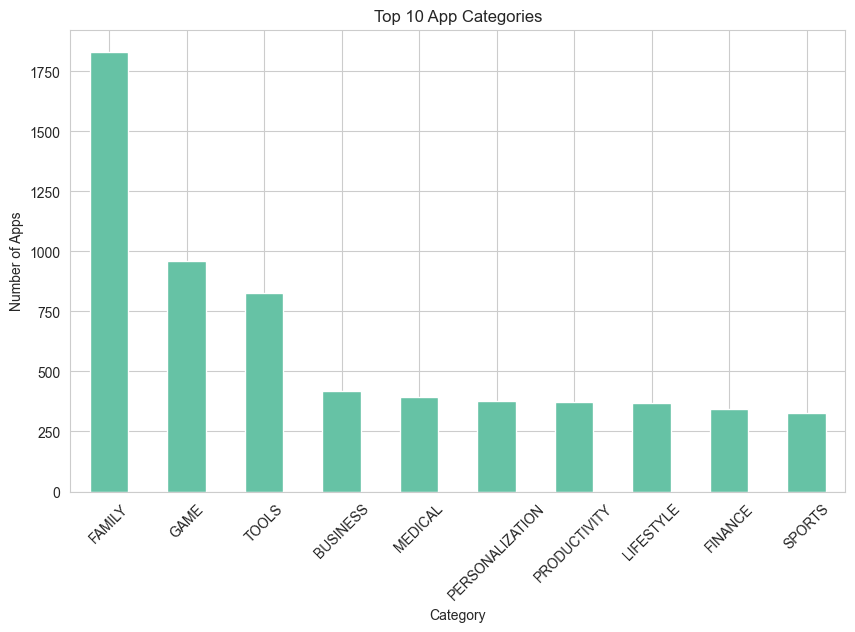

In [22]:
plt.figure(figsize=(10,6))
apps['Category'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 App Categories")
plt.xlabel("Category")
plt.ylabel("Number of Apps")
plt.xticks(rotation=45)
plt.show()

Most applications belong to the Family category, indicating high competition in this segment. This suggests that developers frequently target general-purpose and family-friendly audiences.

### ⭐ *Ratings Distribution*

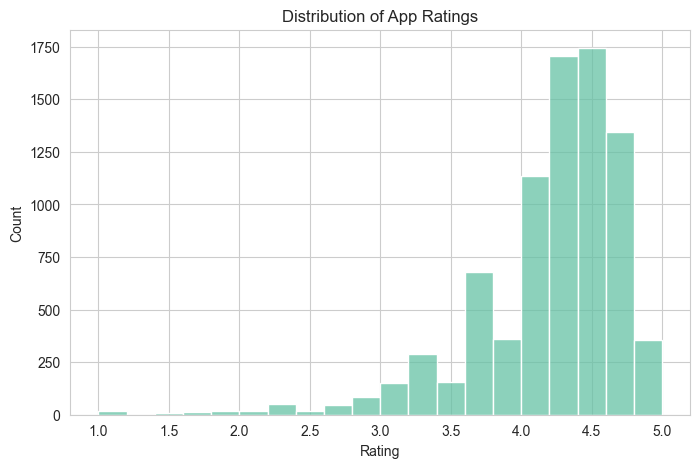

In [23]:
plt.figure(figsize=(8,5))
sns.histplot(apps['Rating'], bins=20)
plt.title("Distribution of App Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

Most apps have ratings between 4.0 and 5.0, indicating generally high user satisfaction. Low-rated apps are relatively rare.

### 📈 *Installs vs Rating*

c:\Users\NIKITA\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


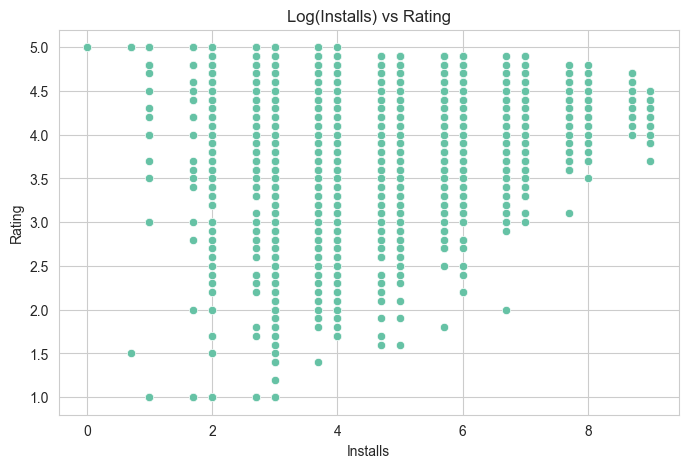

In [35]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=np.log10(apps['Installs']), y='Rating', data= apps)
plt.title("Log(Installs) vs Rating")
plt.show()

There is no strong relationship between installs and ratings. Popular apps do not necessarily have higher ratings.

### 💰 *Free vs Paid Apps*

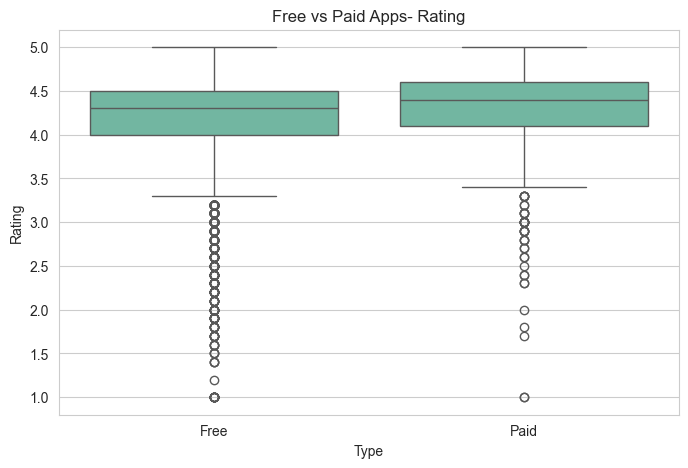

In [36]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Type', y='Rating', data=apps)
plt.title("Free vs Paid Apps- Rating")
plt.show()

Paid apps tend to have slightly higher and more consistent ratings, while free apps show greater variability in quality.

### 📦 *Rating by Category*

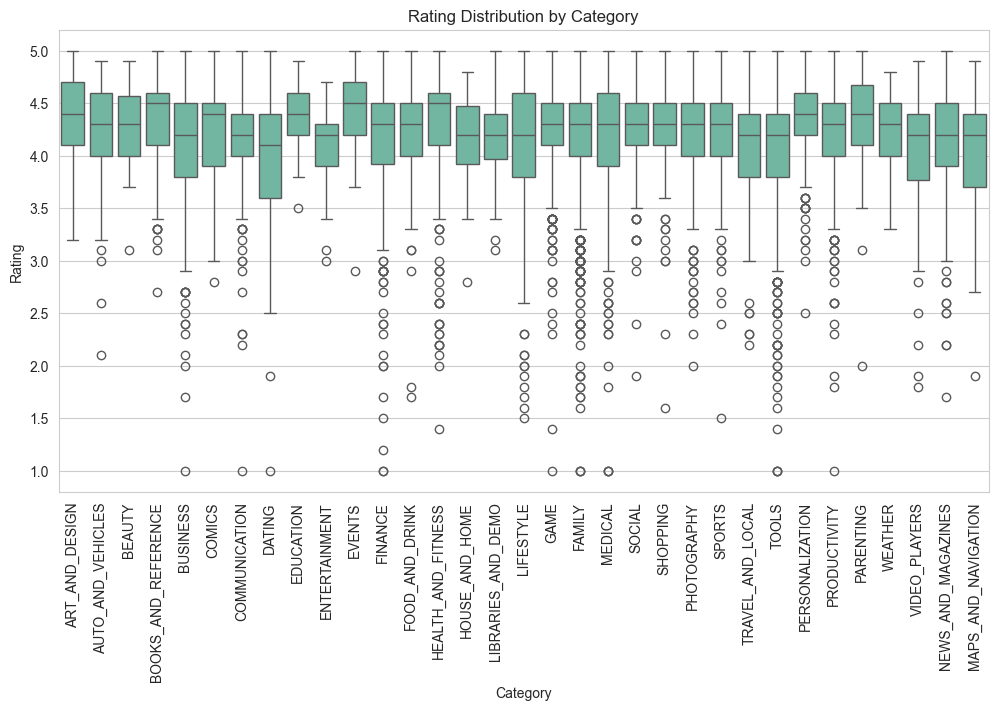

In [26]:
plt.figure(figsize=(12,6))
sns.boxplot(x='Category', y='Rating', data=apps)
plt.xticks(rotation=90)
plt.title("Rating Distribution by Category")
plt.show()

Most categories have high average ratings, but categories like Games and Family show higher variability, indicating inconsistent app quality.

### 💰 *Price Distribution*

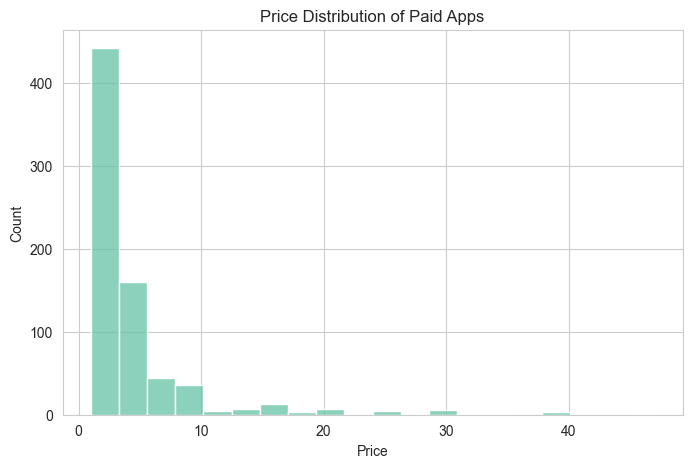

In [27]:
paid_apps = apps[apps['Price'] > 0]

plt.figure(figsize=(8,5))
sns.histplot(paid_apps[paid_apps['Price'] < 50]['Price'], bins=20)
plt.title("Price Distribution of Paid Apps")
plt.show()

Most paid apps are priced below $5, indicating that developers prefer affordable pricing strategies to attract users.

### 📈 *Installs Distribution*

c:\Users\NIKITA\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


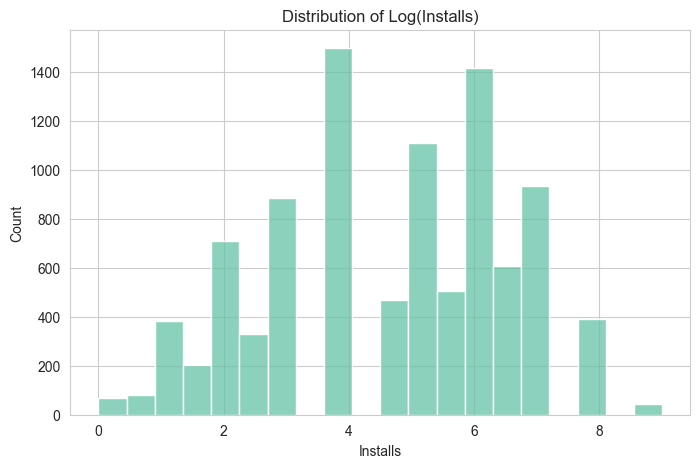

In [28]:
plt.figure(figsize=(8,5))
sns.histplot(np.log10(apps['Installs']), bins=20)
plt.title("Distribution of Log(Installs)")
plt.show()

Most apps fall within the moderate install range (10,000 to 1,000,000). Only a small number of apps achieve extremely high popularity.

### 📊 *Correlation Analysis*

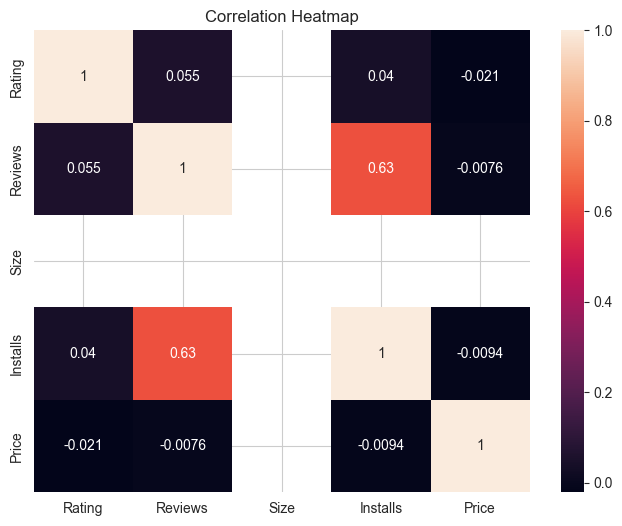

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(apps.corr(numeric_only=True),annot=True)
plt.title("Correlation Heatmap")
plt.show()

Installs and reviews show a strong positive correlation, while ratings have weak correlation with other variables, indicating that popularity does not strongly influence ratings.

## *Sentiment Analysis*

In [30]:
reviews.head()

,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,NaN,NaN,NaN,NaN
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000


In [31]:
reviews= reviews.dropna(subset=['Sentiment'])

### *Sentiment Distribution*

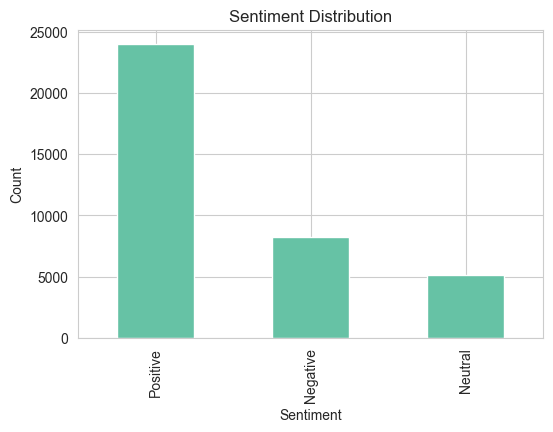

In [32]:
plt.figure(figsize=(6,4))
reviews['Sentiment'].value_counts().plot(kind='bar')
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

Most user reviews are positive, indicating overall satisfaction among users.

In [33]:
merged= pd.merge(apps,reviews, on='App', how='inner')

### *Sentiment vs Rating*

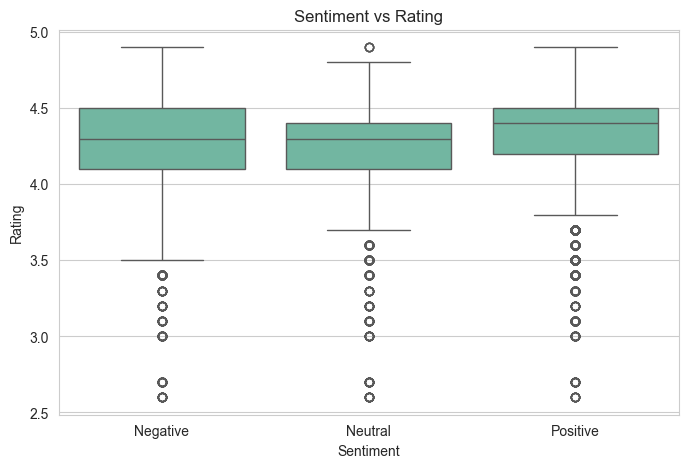

In [34]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Sentiment', y='Rating', data=merged)
plt.title("Sentiment vs Rating")
plt.show()

Apps with positive sentiment have higher ratings, while negative sentiment is associated with lower ratings, confirming alignment between user feedback and ratings.

### 🏁 *Conclusion*

- Most apps are highly rated (4–5 range)
- App popularity does not guarantee higher ratings
- Paid apps show slightly better consistency
- Most apps have moderate installs
- Pricing is mostly low-cost
- User sentiment strongly aligns with ratings

Overall, the Play Store ecosystem shows high competition, moderate success levels, and generally positive user feedback.